


![Descripción de la imagen](https://drive.google.com/uc?export=download&id=1LNMJ1zjBZkWJeZwJO38EJzfOWBHt4u4q)


## **Clase 5 - Tools / Function Calling y Langchain**



# Objetivos de hoy

**Objetivo Alumno:** Comprender cómo los modelos de lenguaje (LLMs) pueden interactuar de manera autónoma con el mundo exterior mediante el uso de herramientas (tools) e integraciones con LangChain.



#Material de Clase
Repositorio de Github

https://github.com/tribu-ia/don-confiado


**Este mismo colab**

https://colab.research.google.com/drive/1e8vNthji_t8kP7eBowrjMfmyxf8GKjk-?usp=sharing (https://colab.research.google.com/drive/1e8vNthji_t8kP7eBowrjMfmyxf8GKjk-?usp=sharing)


URL Corta del Colab: [https://tinyurl.com/tribuia-agent-5](https://tinyurl.com/tribuia-agent-5)


**Colab Clase Anterior**:

https://tinyurl.com/tribuia-agent-5 (https://tinyurl.com/tribuia-agent-5)





## **¿Cómo hacer que un LLM se comunique con el mundo exterior?**

![Imagen desde Drive](https://drive.google.com/uc?export=view&id=1_4PKaii_J7UM0OBorwfTFs922lTPYv5m)

Como modelos de lenguaje los LLM estos se encuentran enjaulados en sus propios "pensamientos" sus entradas como hemos visto son los textos (imágenes, audio o video en los multimodales).


Los modelos de lenguaje **no pueden ejecutar nada**. Pero como pueden pedirnos que ejecutemos cosas por ellos.  Y cuando digo "pueden pedirnos" me refiero al programa que invoca el API.

Para poderlo hacer los LLM deben saber que cuentan con herramientas ( **tools**) que pueden ejecutar. Deben saber para que sirven esas tools. Y deben saber que datos de entradas tienen estas tools.


![Imagen desde Drive](https://drive.google.com/uc?export=view&id=1ydtFEGVvpPi2rOUocPsRqZTzTb80wdVB)


# Tools y Function Calling

Introducimos entonces dos nuevos conceptos:
- Tools
- Function Calling


# Tools

- Nombre: martillo
- Descripción: Esta herramienta sirve para golpear fuertemente, principalmente para claver puntillas
- Datos de Entrada **parameters**: Agarre la herramienta por el mango y aplíquele *fuerza* proporcionalmente a lo que desea clavar.

![Imagen desde Drive](https://drive.google.com/uc?export=view&id=1PMux1ol32yLvYemdmCdxnwfU1WzksYF8)


# Function Calling

Es la instrucción que le da el LLM a quien lo invoque. Los **LLM deciden** si desean o no usar una tool.  E indican los datos de entrada.

El LLM dirá:
- Usa la tool XYZ
- Los parametros de entrada son: a, b, c
- ID de la respuesta. Cuando vuelvas a invocar el LLM la respuesta me la debes marcar con ese ID.


# *NO MAS TEORIA. VAMOS AL CODIGO*

In [2]:
print("Instalando dotenv")
!pip install --quiet python-dotenv

print("Instalando openai")
!pip install --quiet openai

print("Instalando genai")
!pip install --quiet -qU google-genai google-adk
print("Instalando langchain langchain_google_genai langchain_openai ")
!pip install --quiet -qU langchain langchain_google_genai langchain_openai langchain-community langchain-text-splitters
print("INSTALO DE TODO. Langchain langchain_google_genai langchain_openai")

Instalando dotenv
Instalando openai
Instalando genai
Instalando langchain langchain_google_genai langchain_openai 
INSTALO DE TODO. Langchain langchain_google_genai langchain_openai


## Cargamos las llaves 🔑


Ahora vamos a poner las llaves o (API_KEYS) de cada plataforma


Recuerden crear los API KEYS de Google Gemini y OpenAI

Google Gemini:  https://aistudio.google.com/api-keys

OpenAI: https://platform.openai.com/api-keys


Te las pedirá o las puedes guardar para usos futuros.


In [3]:
import os
from google.colab import userdata
from dotenv import load_dotenv

load_dotenv()


def assign_key(userdata,key_name:str, input_message:str, hint:str = None):
  try:
    from google.colab import userdata
    IN_COLAB = True
  except ImportError:
    IN_COLAB = False

  if IN_COLAB:
    try:
      key = userdata.get(key_name)
      if key:
        os.environ[key_name] = key
        return os.environ[key_name]
    except:
      return os.environ[key_name]

  if hint:
    print(hint)
  key = input(input_message)
  os.environ[key_name] = key
  return os.environ[key_name]



gemini_api_key = assign_key(userdata, "GEMINI_API_KEY", "Por favor, ingrese su API KEY de Gemini: ","Para obtener Gemini API Key https://aistudio.google.com/")
openai_api_key = assign_key(userdata, "OPENAI_API_KEY", "Por favor, ingrese su API KEY de OPENAI: " )


print("Ya cargaste las llaves en las variables de entorno")
print("Puedes pasar a probar los APIs")


Ya cargaste las llaves en las variables de entorno
Puedes pasar a probar los APIs


#Definimos algunas funciones útiles para procesar archivos


Como necesitamos procesar archivos vamos a crear unas funciones que nos ayudarán a descargarlas desde Internet y extraer sus bytes

In [ ]:
import requests
import os


# Crearemos algunas funciones útiles para manipular las imágenes.


# Necesitamos cargar los bytes de una imágen en un archivo.
def load_image_bytes(path: str) -> bytes:
    with open(path, "rb") as f:
        return f.read()


#Descargamos la imagen y la guardamos localmente
def descargar_archivo(url: str, destino: str):
    """
    Descarga un archivo desde una URL (por ejemplo, de Google Drive o Imgur)
    y la guarda en la ruta especificada.

    Parámetros:
        url (str): URL directa o de descarga del archivo.
        destino (str): Ruta completa donde guardar el archivo, incluyendo el nombre del archivo.
    """
    print(f"📥 Descargando archivo desde: {url}")

    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(destino, "wb") as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)
        print(f"✅ Archivo descargado correctamente en: {destino}")
    else:
        raise Exception(f"❌ Error al descargar el archivo: {response.status_code}")

    # Verificar que el archivo existe y tiene contenido
    if not os.path.exists(destino) or os.path.getsize(destino) == 0:
        raise FileNotFoundError("❌ No se encontró el archivo o está vacio")
    else:
        print(f"📏 Tamaño del archivo: {os.path.getsize(destino)} bytes")

# Ejemplo de uso:
# descargar archivo("https://drive.google.com/uc?export=download&id=1PMXWYR_hekobCV0jSrFEz5TpIjriU6jM", "/content/imagen_imgur.png")

def descargar_archivo_a_variable(url:str, filename:str) -> str:
  descargar_archivo(url, filename)
  with open(filename, "r", encoding="utf-8") as f:
    return f.read()





In [4]:
productos = [
  {"nombre": "BARRA DE CEREAL TOSH FRESA x23", "precio": 1200},
  {"nombre": "BARRA DE CEREAL TOSH SABORES x6und", "precio": 7950},
  {"nombre": "CAFE COLCAFE 3 EN 1 SOBRE x19und", "precio": 700},
  {"nombre": "CAFE COLCAFE POLVO x250gr", "precio": 15990},
  {"nombre": "CAFE COLCAFE VAINILLA x50gr", "precio": 6400},
  {"nombre": "CAPUCHINO COLCAFE CLASICO x18sbr", "precio": 10550},
  {"nombre": "CAPUCHINO COLCAFE CLASICO x6sbr x18gr", "precio": 4850},
  {"nombre": "CHOCOLATE CHOCOLYNE BOLSA SPLENDA x120gr", "precio": 5500},
  {"nombre": "CHOCOLATE CHOCOLYNE CLAVOS Y CANELA BOLSA x120gr", "precio": 5900},
  {"nombre": "CHOCOLATE CHOCOLYNE SPLENDA BOLSA x120gr", "precio": 6400},
  {"nombre": "CHOCOLATE CHOCOLYNE SPLENDA CLASIC BARRA x156gr", "precio": 5100},
  {"nombre": "CHOCOLATE CORONA AZUCAR x250gr", "precio": 7950},
  {"nombre": "CHOCOLATE CORONA AZUCAR x500gr", "precio": 13950},
  {"nombre": "CHOCOLATE CORONA CLAVOS Y CANELA x250gr", "precio": 7950},
  {"nombre": "CHOCOLATINA GOL x31gr", "precio": 2500},
  {"nombre": "CHOCOLATINA JET BURBUJET VAINILLA", "precio": 5500},
  {"nombre": "CHOCOLATINA JET CREMA x18gr", "precio": 1190},
  {"nombre": "CHOCOLATINA JUMBO FLOW BLANCA x18gr", "precio": 1190},
  {"nombre": "CHOCOLATINA JUMBO FLOW BLANCA x48gr", "precio": 2500},
  {"nombre": "CHOCOLATINA JUMBO JET x100", "precio": 9000},
  {"nombre": "CHOCOLATINA JUMBO JET x40gr", "precio": 4800},
  {"nombre": "CHOCOLATINA JUMBO KREMANI x40gr", "precio": 1800},
  {"nombre": "CHOCOLATINA JUMBO MINI", "precio": 1500},
  {"nombre": "CHOCOLATINA JUMBO MIX", "precio": 5200},
  {"nombre": "CHOCOLATINA MONTBLANC x60gr", "precio": 4900},
  {"nombre": "CHOCOLISTO CROCANTE x100g", "precio": 3400},
  {"nombre": "CHOCOLISTO FAMIPACK x440gr", "precio": 10591},
  {"nombre": "GALLETA WAFER JET VAINILLA x22gr", "precio": 2600},
  {"nombre": "GALLETAS DUCALES PROVOCACION x6und", "precio": 6400},
  {"nombre": "GALLETAS DUCALES TENTACION TACO REF x160g", "precio": 3900},
  {"nombre": "GALLETAS DUCALES TENTACION TACO REF x160grs", "precio": 2950},
  {"nombre": "GALLETAS DUCALES x441g", "precio": 9300},
  {"nombre": "GALLETAS DUCALES x441grs", "precio": 8330},
  {"nombre": "GALLETAS DUCALES x9", "precio": 3450},
  {"nombre": "GALLETAS SALTIN 6 TACOS", "precio": 7650},
  {"nombre": "GALLETAS SALTIN INTEGRAL DOBLE FIBRA x9", "precio": 3450},
  {"nombre": "GALLETAS SALTIN QUESO MANTEQUILLA x9", "precio": 4300},
  {"nombre": "GALLETAS SALTIN SEMILLAS Y CAREALES 3 TACOS", "precio": 6600},
  {"nombre": "GALLETAS SALTIN TACO x110gr", "precio": 1500},
  {"nombre": "GALLETAS SALTIN TRIGO Y MAIZ 3 TACOS", "precio": 4350},
  {"nombre": "GALLETAS SALTIN x9", "precio": 3450},
  {"nombre": "MAIZ TOSTADO LA ESPECIAL x40gr", "precio": 1400},
  {"nombre": "MANI EL MANICERO x25gr", "precio": 1000},
  {"nombre": "MANI LA ESPECIAL ARANDANOS x45gr", "precio": 2100},
  {"nombre": "MANI LA ESPECIAL BARRA x38gr", "precio": 3000},
  {"nombre": "MANI LA ESPECIAL CON CHOCOLATES x44gr", "precio": 1900},
  {"nombre": "MANI LA ESPECIAL CON PASAS x50gr", "precio": 1600},
  {"nombre": "MANI LA ESPECIAL KRAKS x30gr", "precio": 900},
  {"nombre": "MANI LA ESPECIAL LIMON PIMIENTA x40gr", "precio": 3000},
  {"nombre": "MANI LA ESPECIAL MIX ALMENDRAS", "precio": 2200},
  {"nombre": "MANI LA ESPECIAL x50gr", "precio": 2975},
  {"nombre": "PASTA DORIA ESPAGUETTI AL HUEVO x250gr", "precio": 2750},
  {"nombre": "PASTA DORIA LASAGNA x200gr", "precio": 5250},
  {"nombre": "PASTA DORIA RANCHERO SPAGUETTI x250gr", "precio": 2750},
  {"nombre": "PASTA DORIA SPAGUETI POLLO x250gr", "precio": 2750},
  {"nombre": "PASTA DORIA SPAGUETI TOMATE x250gr", "precio": 2750},
  {"nombre": "PASTA DORIA SPAGUETTI MANTEQUILLA x220gr", "precio": 2750},
  {"nombre": "PASTA DORIA SPAGUETTI VERDURAS x250gr", "precio": 2750},
  {"nombre": "PASTA DORIA SPAGUETTI x500gr", "precio": 4200},
  {"nombre": "PASTA DORIA TORNILLOS VERDURAS x250gr", "precio": 2290},
    {"nombre": "BEBIDA GASIFICADA SABOR A VINO MOSTELO BLANCO x750ml", "precio": 13000},
  {"nombre": "BEBIDA SCHW X1,75LT SODA", "precio": 3500},
  {"nombre": "GASEOSA POSTOBON ACQUA FRUTOS ROJOS x1.5lt", "precio": 3000},
  {"nombre": "GASEOSA POSTOBON MANZANA x400ml", "precio": 2700},
  {"nombre": "GASEOSA 7UP SABOR A LIMA LIMON x2lt", "precio": 0},
  {"nombre": "GASEOSA BIG COLA LIMON x3.020lt", "precio": 3800},
  {"nombre": "GASEOSA BIG COLA x1700ml", "precio": 2100},
  {"nombre": "GASEOSA BIG COLA x3,020lt", "precio": 3750},
  {"nombre": "GASEOSA BIG COLA x400ml", "precio": 0},
  {"nombre": "GASEOSA BIG MANZANA x400ml", "precio": 0},
  {"nombre": "GASEOSA CANADA DRY X 2.5 LT", "precio": 5500},
  {"nombre": "GASEOSA CANADA DRY x400ml", "precio": 0},
  {"nombre": "GASEOSA COCA COLA CERO PLAST x250ml", "precio": 1785},
  {"nombre": "GASEOSA COCA COLA CON CAFE LATA x235ml", "precio": 0},
  {"nombre": "GASEOSA COCA COLA LIGHT x1,5ml", "precio": 5400},
  {"nombre": "GASEOSA COCA COLA OFERTA BT x1,5lt x2und", "precio": 6570},
  {"nombre": "GASEOSA COCA COLA PLAST x250ml", "precio": 2500},
  {"nombre": "GASEOSA COCA COLA PLAST x400ml", "precio": 4000},
  {"nombre": "GASEOSA COCA COLA SIN AZUCAR x400ml", "precio": 2500},
  {"nombre": "GASEOSA COCA COLA SIN CALORIAS SIN AZUCAR x600ml", "precio": 3400},
  {"nombre": "GASEOSA COCA COLA SIXPACK x235ml", "precio": 8750},
  {"nombre": "GASEOSA COCA COLA x1.5lts", "precio": 3500},
  {"nombre": "GASEOSA COCA COLA x1500ml", "precio": 5500},
  {"nombre": "GASEOSA COCA COLA x2000ml", "precio": 0},
  {"nombre": "GASEOSA COCA COLA x3lts", "precio": 9000},
  {"nombre": "GASEOSA COCA COLA ZERO x1.5ml", "precio": 7000},
  {"nombre": "GASEOSA COCA COLA ZERO x2,5lt", "precio": 5300},
  {"nombre": "GASEOSA COCA-COLA SIN AZÚCAR x330ml", "precio": 1400},
  {"nombre": "GASEOSA COLA ROMAN x1500ml", "precio": 4500},
  {"nombre": "GASEOSA FRIZZ FRUTOS ROJOS x1500ml", "precio": 3000},
  {"nombre": "GASEOSA GLACIAL MANZANA x1lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL MANZANA x400ml", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL COLA NEGRA x1.7lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL COLA NEGRA x1lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL CREMA SODA TIPO COLOMBIANA x1.7lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL CREMA SODA TIPO COLOMBIANA x1lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL CREMA SODA TIPO COLOMBIANA x400ml", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL KOLA ROJA TIPO PREMO x1.7lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL KOLA ROJA TIPO PREMO x1lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL KOLA ROJA TIPO PREMO x3,05 lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL LIMA LIMON x1.7lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL LIMA LIMON x3,05lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL LIMA LIMON x400ml", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL NARANJA x1.7lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL NARANJA x400ml", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL UVA x1lt", "precio": 999999},
  {"nombre": "GASEOSA GLACIAL UVA x3,05lt", "precio": 999999}
]


##------------------------------------------------------
#buscar_productos
# Esta es la funcion que vamos a convertir en tool
#---------------------------------------------------------
def buscar_productos(texto_busqueda: str) -> list[dict]:
    global  productos
    # Normaliza el texto y separa por palabras
    palabras = [p.lower() for p in texto_busqueda.strip().split() if p]

    # Filtra los productos que contienen todas las palabras
    resultados = []
    for prod in productos:
        nombre = prod.get("nombre", "").lower()
        if all(palabra in nombre for palabra in palabras):
            resultados.append(prod)
    return resultados


resultados = buscar_productos("GLACIAL UVA")

for r in resultados:
    print(r)


{'nombre': 'GASEOSA GLACIAL UVA x1lt', 'precio': 999999}
{'nombre': 'GASEOSA GLACIAL UVA x3,05lt', 'precio': 999999}


*texto en cursiva*# Haremos el llamado directamente al API del LLM / Gemini


![](https://drive.google.com/uc?export=view&id=1_uNd687XCjEu4UZOJXhh-mwJ3BjROo3D)





In [5]:

nombre_de_la_tool = "buscar_productos"
descripcion_de_la_tool = """
Puedes usar esta herramienta para buscar productos por nombre. Puedes usar nombres parciales.
Para llamar la función debes mandar el nombre del producto en mayúsculas.

Esta herramienta retornará el producto con su nombre, precios.

La puedes usar si te piden precios de cierto tipos de productos

"""
parametros_de_la_tool = {
                             "type":"object",
                             "properties": {
                                   "texto_busqueda": {
                                       "type": "string",
                                       "description":"Nombre del producto en mayuscula"
                                    }

                              },
                              "required": ["texto_busqueda"]
                         }


# Define a function that the model can call to control smart lights
definicion_de_la_tool = {
    "name": nombre_de_la_tool,
    "description": descripcion_de_la_tool,
    "parameters": parametros_de_la_tool
}




In [ ]:
##============================================
##   LLAMAMOS LA TOOL
##============================================
from google import genai
from google.genai import types

# Configure the client and tools
client = genai.Client()
tools = types.Tool(function_declarations=[definicion_de_la_tool])
config = types.GenerateContentConfig(tools=[tools])

# Define user prompt
contents = [
    types.Content(
        role="user", parts=[types.Part(text="cuanto valen las galletas saltin")]
    )
]

# Send request with function declarations
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=contents,
    config=config,
)



print(response)

#  Revisamos si nos pide invocar una tool
tool_call = response.candidates[0].content.parts[0].function_call

if tool_call and tool_call.name == nombre_de_la_tool:
    result = buscar_productos(**tool_call.args)
    print("--------------------------------------------")
    print(f"Function execution result: {result}")
    print("--------------------------------------------")


    # Create a function response part
    function_response_part = types.Part.from_function_response( name=tool_call.name, response={"result": result})

    # Append function call and result of the function execution to contents
    contents.append(response.candidates[0].content) # Append the content from the model's response.
    contents.append(types.Content(role="user", parts=[function_response_part])) # Append the function response

    segundo_llamado = client.models.generate_content(model="gemini-2.5-flash",config=config,contents=contents)
    print("--------------- RESPUESTA ----------------")
    print(segundo_llamado.candidates[0].content.parts[0].text)
else:
  print(response.candidates[0].content.parts[0].text)



## Creamos los Modelos (LLM) enLangchain

![image.png](https://drive.google.com/uc?export=download&id=1UbD5tXczZlVJ3xWH6L4eDk4fn-XkfI3V)






Se repiten los casos de clases pasadas para crear los clientes de LLM

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage , AIMessage

openai_model = init_chat_model("gpt-4.1-mini",      model_provider="openai",        api_key=openai_api_key)
gemini_model = init_chat_model("gemini-2.0-flash",  model_provider="google_genai",   api_key=gemini_api_key)

print("LLMs cargados")



LLMs cargados


## Con langchain todo se simplifica mucho.








In [8]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage



#------------------------------------------------------
# AQUI VAN LAS TOOLS
# Lo colocamos la anotación en @tool en cada una
#---------------------------------------------------------
@tool
def buscar_productos_tool(texto_busqueda: str) -> list[dict]:
    """
    Puedes usar esta herramienta para buscar productos por nombre. Puedes usar nombres parciales.
    Para llamar la función debes mandar el nombre del producto en mayúsculas.

    Esta herramienta retornará el producto con su nombre, precios.

    La puedes usar si te piden precios de cierto tipos de productos

    """
    global  productos
    # Normaliza el texto y separa por palabras
    palabras = [p.lower() for p in texto_busqueda.strip().split() if p]

    # Filtra los productos que contienen todas las palabras
    resultados = []
    for prod in productos:
        nombre = prod.get("nombre", "").lower()
        if all(palabra in nombre for palabra in palabras):
            resultados.append(prod)
    return resultados

@tool
def buscar_por_rango_de_precio(minimo: float, maximo: float) -> list[dict]:
    """
    """

    global  productos
    resp = []
    for p in productos:
      if minimo <= p["precio"]  and p["precio"] <= maximo:
        resp.append(p)
    return resp


##-----------------[ FIN DE LAS TOOLS] ------------------------



tools = [buscar_productos_tool,buscar_por_rango_de_precio]
tools_dict = {
    "buscar_productos_tool":buscar_productos_tool,
    "buscar_por_rango_de_precio":buscar_por_rango_de_precio
}
llm_with_tools = gemini_model.bind_tools(tools)


pregunta = "Cuanto valen las galletas saltin"

messages = [HumanMessage(pregunta)]

ai_msg = llm_with_tools.invoke(messages)


print(type(ai_msg))
print(ai_msg.tool_calls)

messages.append(ai_msg)


for tool_call in ai_msg.tool_calls:
    selected_tool = tools_dict[tool_call["name"].lower()]
    tool_msg = selected_tool.invoke(tool_call)
    messages.append(tool_msg)


ai_msg = llm_with_tools.invoke(messages)
print(ai_msg)
print(ai_msg.content)



<class 'langchain_core.messages.ai.AIMessage'>
[{'name': 'buscar_productos_tool', 'args': {'texto_busqueda': 'GALLETAS SALTIN'}, 'id': '439cdee4-634f-4f56-bcb5-af6c23c47526', 'type': 'tool_call'}]
content='Las galletas Saltin tienen los siguientes precios:\nGALLETAS SALTIN 6 TACOS: $7650\nGALLETAS SALTIN INTEGRAL DOBLE FIBRA x9: $3450\nGALLETAS SALTIN QUESO MANTEQUILLA x9: $4300\nGALLETAS SALTIN SEMILLAS Y CAREALES 3 TACOS: $6600\nGALLETAS SALTIN TACO x110gr: $1500\nGALLETAS SALTIN TRIGO Y MAIZ 3 TACOS: $4350\nGALLETAS SALTIN x9: $3450' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--61f26d99-ade5-4f27-a153-fa61adb5e682-0' usage_metadata={'input_tokens': 226, 'output_tokens': 142, 'total_tokens': 368, 'input_token_details': {'cache_read': 0}}
Las galletas Saltin tienen los siguientes precios:
GALLETAS SALTIN

## ===================================================
## MAS INTERACTIVO  Y CONVERSACIONAL
## ===================================================


In [ ]:

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage



#------------------------------------------------------
# AQUI VAN LAS TOOLS
# Lo colocamos la anotación en tool en cada una
#---------------------------------------------------------
@tool
def buscar_productos_tool(texto_busqueda: str) -> list[dict]:
    """
    Puedes usar esta herramienta para buscar productos por nombre. Puedes usar nombres parciales.
    Para llamar la función debes mandar el nombre del producto en mayúsculas.

    Esta herramienta retornará el producto con su nombre, precios.

    La puedes usar si te piden precios de cierto tipos de productos

    """
    global  productos
    # Normaliza el texto y separa por palabras
    palabras = [p.lower() for p in texto_busqueda.strip().split() if p]

    # Filtra los productos que contienen todas las palabras
    resultados = []
    for prod in productos:
        nombre = prod.get("nombre", "").lower()
        if all(palabra in nombre for palabra in palabras):
            resultados.append(prod)
    return resultados

@tool
def buscar_por_rango_de_precio(minimo: float, maximo: float) -> list[dict]:
    """
    Busca productos por rango de precio
    """

    global  productos
    resp = []
    for p in productos:
      if minimo <= p["precio"]  and p["precio"] <= maximo:
        resp.append(p)
    return resp


# --- NUEVA TOOL: Detectar despedidas ---

finalizar_chat = False

@tool
def detectar_despedida_tool(texto: str):
    """Debes invocar esta tool cuando el usuario se despida ."""
    global finalizar_chat
    finalizar_chat = True
    return True

##-----------------[ FIN DE LAS TOOLS] ------------------------


In [ ]:

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# --- Diccionario de tools ---
tools = [buscar_productos_tool, buscar_por_rango_de_precio, detectar_despedida_tool]

tools_dict = {
    "buscar_productos_tool": buscar_productos_tool,
    "buscar_por_rango_de_precio": buscar_por_rango_de_precio,
    "detectar_despedida_tool": detectar_despedida_tool,
}

llm_with_tools = gemini_model.bind_tools(tools)

messages = [SystemMessage(content="Eres Don Confiado el bot de IA. Asistente de la comunidad de TribuIA")]
finalizar_chat = False
while not finalizar_chat:
    pregunta = input("Tú: ")
    messages.append(HumanMessage(pregunta))
    ai_msg = llm_with_tools.invoke(messages)
    messages.append(ai_msg)

    # Si el modelo llama a herramientas
    while  ai_msg.tool_calls:
        for tool_call in ai_msg.tool_calls:
             tool_name = tool_call["name"]
             selected_tool = tools_dict[tool_name]
             tool_msg = selected_tool.invoke(tool_call)
             messages.append(tool_msg)

             # Reinvocar el modelo con la respuesta de las tools
             ai_msg = llm_with_tools.invoke(messages)
             messages.append(ai_msg)
    print(f"🤖 {ai_msg.content}\n")
print("TERMINO CONVERSACION")
for m in messages:
  print(m)

# LANGGRAPH

Pongámosle orden a esto con GRAFOs


In [ ]:
from langchain.agents import create_tool_calling_agent
!pip install  langgraph

In [ ]:


from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=gemini_model,
    tools=tools)




resp = agent.invoke({"messages":HumanMessage(content="Tienes saltin?")})
print(type(resp))
print(resp)

![image.png](https://drive.google.com/uc?export=download&id=1jEo5y_2L_isMWzfGU2s-mKoK0vFFjA5D
)

# Por q langGraph?

Porque **LangGraph** hace que crear agentes sea mucho más fácil y ordenado. En lugar de escribir todo desde cero en Python, puedes **conectar pasos y decisiones como si armaras un mapa**, viendo cómo fluye la conversación y qué hace cada parte del agente. Así entiendes mejor el proceso y puedes mejorar tus agentes sin complicarte con tanto código.


![image.png](https://drive.google.com/uc?export=download&id=1rdfx7o_EQibpFHauhGQ57eeBoOIpkeU6
)



## Como ejecutar un flujo en langGraph:

### Conceptos que necesitamos saber:

* Punto de partida: donde inicia el flujo del agente.
* Nodo: una acción o paso dentro del flujo.
* Estado: la información que el agente guarda y actualiza durante el proceso.
* Finalizar: el punto donde el flujo termina y el agente entrega su resultado.

![image.png](https://drive.google.com/uc?export=download&id=1Z-r9nrtxvghbUx3jlIfeYIZkbfqst1oI
)

In [ ]:
from langgraph.graph import StateGraph, START, END

# Definimos una función sencilla (nodo del grafo)
def hola_langgraph(state):
    print("🧩 Ejecutando nodo: Hola LangGraph")
    return {"saludo": "¡Hola desde LangGraph!"}

# Creamos el grafo
graph = StateGraph(dict)
graph.add_node("hola", hola_langgraph)
graph.add_edge(START, "hola")
graph.add_edge("hola", END)

# Compilamos y ejecutamos
runnable = graph.compile()
runnable.invoke({})


In [ ]:
from IPython.display import Image, display

display(Image(runnable.get_graph().draw_mermaid_png()))

In [ ]:
from langchain.tools import tool

# Definimos una herramienta: sumar dos números
@tool
def suma(a: int, b: int) -> int:
    """Suma dos números enteros"""
    return a + b

# Creamos un nodo que use la herramienta
def nodo_suma(state):
    resultado = suma.invoke({"a": 3, "b": 5})
    print("🧮 Resultado herramienta:", resultado)
    return {"resultado": resultado}

# Nuevo grafo con START → suma → END
graph2 = StateGraph(dict)
graph2.add_node("sumar", nodo_suma)
graph2.add_edge(START, "sumar")
graph2.add_edge("sumar", END)

runnable2 = graph2.compile()
runnable2.invoke({})

In [ ]:
from IPython.display import Image, display

display(Image(runnable2.get_graph().draw_mermaid_png()))

In [ ]:
def verificar_par(state):
    n = state.get("numero", 0)
    if n % 2 == 0:
        print(f"✅ {n} es par")
        return {"mensaje": f"{n} es par"}
    else:
        print(f"⚠️ {n} es impar")
        return {"mensaje": f"{n} es impar"}

graph3 = StateGraph(dict)
graph3.add_node("verificar", verificar_par)
graph3.add_edge(START, "verificar")
graph3.add_edge("verificar", END)
runnable3 = graph3.compile()

# Probar
runnable3.invoke({"numero": 7})

In [ ]:
from IPython.display import Image, display
display(Image(runnable3.get_graph().draw_mermaid_png()))


In [ ]:
from langgraph.graph import StateGraph, END, START
from typing import Literal

def number(state):
  pass

def verificar_par(state)->Literal["par", "impar"]:
    """
    Verifica si el número es par o impar y devuelve la clave
    de enrutamiento para la gráfica.
    """
    n = state.get("numero", 0)
    if n % 2 == 0:
        return "par" # Devuelve la clave 'par'
    else:
        return "impar" # Devuelve la clave 'impar'

def es_par_print(state):
    """Nodo que se ejecuta si el número es par."""
    n = state["numero"]
    print(f"✅ Bifurcación tomada: {n} es par")
    return {"mensaje": f"El proceso terminó. {n} es PAR."}

def es_impar_print(state):
    """Nodo que se ejecuta si el número es impar."""
    n = state["numero"]
    print(f"⚠ Bifurcación tomada: {n} es impar")
    return {"mensaje": f"El proceso terminó. {n} es IMPAR."}

# 1. Crear la gráfica de estado
graph3 = StateGraph(dict)

# 2. Agregar los nodos
graph3.add_node("number", number)
graph3.add_node("par", es_par_print)
graph3.add_node("impar", es_impar_print)

# 3. Definir la arista inicial
graph3.add_edge(START, "number")

# 4. Definir la bifurcación condicional
# 'verificar' usará el valor de la clave 'es_par' en el estado
# para decidir a dónde ir.
graph3.add_conditional_edges(
    "number", verificar_par
)

# 5. Definir la salida final para ambos caminos
graph3.add_edge("par", END)
graph3.add_edge("impar", END)

# 6. Compilar y ejecutar
runnable3 = graph3.compile()

In [ ]:
print("\n--- Probando con 7 (Impar) ---")
resultado_impar = runnable3.invoke({"numero": 7})
print(f"Resultado final: {resultado_impar}")

# --- Probando con 7 (Impar) ---
# ⚠ Bifurcación tomada: 7 es impar
# Resultado final: {'es_par': 'impar', 'numero': 7, 'mensaje': 'El proceso terminó. 7 es IMPAR.'}

### Graph 4 nodos - guardrails

In [ ]:
# ===============================
# 🧩 INSTALACIÓN DE DEPENDENCIAS
# ===============================
!pip install -qU langchain langgraph langchain-openai

# ===============================
# 🔐 CONFIGURAR CLAVE OPENAI
# ===============================
import os
from getpass import getpass

# Ingresa tu clave (no quedará visible)
os.environ["OPENAI_API_KEY"] = getpass("Introduce tu OpenAI API Key: ")

# ===============================
# 📦 IMPORTAR LIBRERÍAS NECESARIAS
# ===============================
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional
import re, json

# ===============================
# 📌 DEFINIR EL ESTADO DEL GRAFO
# ===============================
class GraphState(TypedDict):
    input_text: str
    validated_text: Optional[str]
    model_output: Optional[str]
    final_response: Optional[str]

# ===============================
# 🟢 NODO 1: ENTRADA
# ===============================
def nodo_entrada(state: GraphState):
    print("🔹 Nodo Entrada ejecutado")
    return {"validated_text": state["input_text"]}

# ===============================
# 🟠 NODO 2: VALIDACIÓN (GUARDRAILS) : Garantizar que la IA actúe con seguridad, ética y responsabilidad.
    #Ejemplo:
      #Bloquear respuestas violentas, sesgadas o ilegales.
      #Evitar que un modelo ejecute funciones peligrosas o acceda a datos sensibles.
      #Asegurar que las respuestas sigan principios éticos o políticas de uso.
# ===============================
def nodo_validacion(state: GraphState):
    print("🧱 Nodo Validación ejecutado")
    text = state["validated_text"]
    # Reglas básicas de seguridad: bloquear texto ofensivo
    if re.search(r"(malo|prohibido|ofensivo)", text.lower()):
        text = "[Contenido bloqueado por guardrail]"
    return {"validated_text": text}

# ===============================
# 🔵 NODO 3: LLM (CON FUNCTION CALLING)
# ===============================
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def nodo_llm(state: GraphState):
    print("🤖 Nodo LLM ejecutado")

    # Definimos la función que el modelo puede llamar
    tools = [{
        "name": "generate_response",
        "description": "Genera una respuesta final en base al texto validado",
        "parameters": {
            "type": "object",
            "properties": {
                "mensaje": {"type": "string", "description": "Texto de entrada validado"}
            },
            "required": ["mensaje"]
        }
    }]

    # Mensajes para el modelo
    messages = [
        {"role": "system", "content": "Eres un asistente amable que decide si debe generar una respuesta."},
        {"role": "user", "content": state["validated_text"]}
    ]

    # ✅ Function calling actualizado (solo 'auto' o 'none')
    response = llm.invoke(messages, functions=tools, function_call="auto")

    # Obtener la llamada a función si existe
    #Obtiene la parte de la respuesta del modelo que indica si éste pidió ejecutar un function calling, si no la hay, deja un diccionario vacío.
    function_call = response.additional_kwargs.get("function_call", {})
    if function_call:
        return {"model_output": function_call.get("arguments", "{}")}
    else:
        return {"model_output": '{"mensaje": "Contenido bloqueado por guardrail, Ojo revisa la ética y responsabilidad con la que se construyó esta solución"}'}

# ===============================
# 🟣 NODO 4: GENERADOR DE RESPUESTA
# ===============================
def nodo_generador_respuesta(state: GraphState):
    print("💬 Nodo Generador de Respuesta ejecutado")
    try:
      #Convierte el texto que está guardado en string en un diccionario de python llamado args.
        args = json.loads(state["model_output"])
        #Busca dentro de ese diccionario el valor asociado a la clave "mensaje".
        mensaje = args.get("mensaje", "")
        return {"final_response": f"✅ Respuesta generada por el agente: '{mensaje}'"}
    except Exception as e:
        return {"final_response": f"⚠️ Error procesando la respuesta: {e}"}

# ===============================
# 🧩 CONSTRUIR EL GRAFO LANGGRAPH
# ===============================
graph = StateGraph(GraphState)

graph.add_node("Entrada", nodo_entrada)
graph.add_node("Validacion", nodo_validacion)
graph.add_node("LLM", nodo_llm)
graph.add_node("Generador", nodo_generador_respuesta)

# Definir el flujo de nodos
graph.add_edge(START, "Entrada")
graph.add_edge("Entrada", "Validacion")
graph.add_edge("Validacion", "LLM")
graph.add_edge("LLM", "Generador")
graph.add_edge("Generador", END)

# Compilar el grafo
app = graph.compile()

# ===============================
# 🚀 EJECUTAR EL FLUJO COMPLETO
# ===============================
#entrada_usuario = "Hola, ¿puedes darme un mensaje motivacional?"
#entrada_usuario = "Hola, ¿usar IA sin contexto o etica es ofensivo?"
entrada_usuario = "Hola, ¿usar IA sin contexto o etica es prohibido?"
resultado = app.invoke({"input_text": entrada_usuario})

print("\n🔚 Resultado Final del Grafo:")
print(resultado["final_response"])

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# Nodos con RAG y toma de decisiones

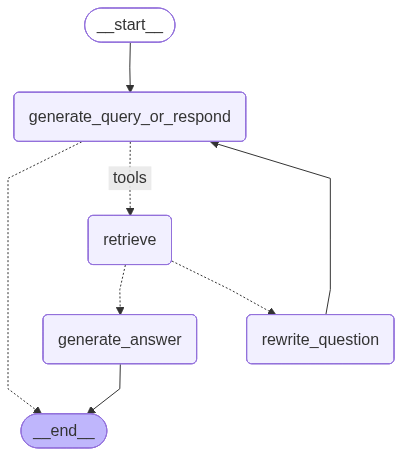


In [ ]:
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://drive.google.com/uc?export=download&id=1zuS1YzxHGqw8vqbf-_A53xXsnYAC2uGb"
]

docs = [WebBaseLoader(url).load() for url in urls]

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=100
)
doc_splits = text_splitter.split_documents(docs_list)

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, embedding=OpenAIEmbeddings()
)
retriever = vectorstore.as_retriever()

In [ ]:
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever, #la funcion retriever
    "retrieve_blog_posts", #nombre de la tool
    "Busca informacion acerca de los equipos y jugadores que jugaron en el mundial sub-20 que se jugo en chile.", #descripcion de la tool
)

In [ ]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

response_model = init_chat_model("openai:gpt-4o", temperature=0)


def generate_query_or_respond(state: MessagesState):
    """Llama al modelo para generar una respuesta basada en el estado actual.
    Dada una pregunta, decidirá si debe recuperar información usando la herramienta de recuperación o simplemente responder al usuario.
    """

    response = (
        response_model
        .bind_tools([retriever_tool]).invoke(state["messages"])
    )
    return {"messages": [response]}

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "Eres un evaluador que califica la relevancia de un documento recuperado con respecto a una pregunta del usuario. \n"
    "A continuación se muestra el documento recuperado: \n\n {context} \n\n"
    "Aquí está la pregunta del usuario: {question} \n"
    "¿Crees que con la búsqueda semántica y los documentos recuperados puedes generar una respuesta? \n"
    "Da una calificación binaria 'sí' o 'no' para indicar si la pregunta puede responderse con los documentos recuperados."
)


class GradeDocuments(BaseModel):
    """Califica los documentos usando una puntuación binaria para verificar su relevancia."""

    binary_score: str = Field(
        description="Calificación de relevancia: 'sí' si es relevante, o 'no' si no lo es."
    )


grader_model = init_chat_model("openai:gpt-4o", temperature=0)


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determina si la pregunta puede ser respondida por los documentos recogidos"""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage , AIMessage

REWRITE_PROMPT = (
    "Mira la pregunta e intenta razonar sobre la intención del usuario y el significado semántico esperado.\n"
    "Aquí está la pregunta inicial:\n"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Redacta una versión mejorada de la pregunta, de forma clara, ingeniosa y enfocada en resolver la inquietud del usuario."
)


def rewrite_question(state: MessagesState):
    """Reescribe la pregunta original del usuario."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    #return {"messages": [{"role": "user", "content": response.content}]}
    return {"messages": [HumanMessage(content=response.content)]}

In [ ]:
GENERATE_PROMPT = (
    "Eres un asistente para tareas de preguntas y respuestas."
    "Usa los siguientes fragmentos de contexto recuperado para responder la pregunta."
    "Si no sabes la respuesta, simplemente indica que no la sabes."
    "Utiliza un máximo de tres oraciones y mantén la respuesta concisa.\n"
    "Pregunta: {question} \n"
    "Contexto: {context}"
)


def generate_answer(state: MessagesState):
    """Generar respuestas"""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

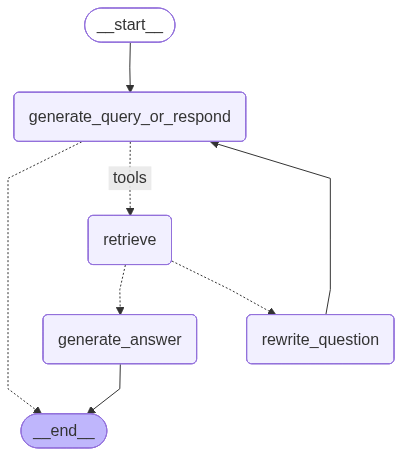

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "En que club juega el arquero del equipo de argentina sub-20, mira la alineacion del equipo",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_8Nie7bt06ennTeUmhTHi78N1)
 Call ID: call_8Nie7bt06ennTeUmhTHi78N1
  Args:
    query: alineación equipo Argentina sub-20 mundial Chile arquero



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

La final del Mundial Sub-20 Chile 2025 se disput√≥ en el Estadio Nacional Julio Mart√≠nez Pr√°danos en Santiago, donde Marruecos gan√≥ su primer t√≠tulo en esta categor√≠a al vencer 2-0 a Argentina. Los goles del partido fueron anotados por Yassir Zabiri, delantero de Marruecos, quien se luci√≥ con un doblete en el primer tiempo: primero anot√≥ un golazo de tiro libre al minuto 12 y luego defini√≥ con una volea al 29‚Äô tras un centro por la banda derecha.

Marruecos, dirigido por Mohamed Ouahbi, super√≥ en el torneo a selecciones fuertes como Espa√±a

In [ ]:


# ===============================
# 📦 IMPORTAR LIBRERÍAS NECESARIAS
# ===============================
try:
    from langchain_openai import ChatOpenAI
    from langgraph.graph import StateGraph, START, END
except ImportError:
    print("="*50)
    print("Error: Librerías no encontradas.")
    print("Por favor, instala las dependencias ejecutando:")
    print("\npip install langgraph langchain-openai\n")
    print("="*50)
    exit()

from typing import TypedDict, Optional
import re
import json
import os

# ===============================
# 🔑 CONFIGURACIÓN DE API KEY (¡ACCIÓN REQUERIDA!)
# ===============================
# Pega tu API key de OpenAI aquí para que el script funcione
# os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY_HERE"

# ===============================
# 📌 DEFINIR EL ESTADO DEL GRAFO
# ===============================
class GraphState(TypedDict):
    """
    Define la "memoria" o "inventario" de nuestro grafo.
    Cada nodo puede leer y escribir en estos campos.
    """
    input_text: str                 # La entrada original del usuario
    validated_text: Optional[str]   # El texto después de la validación 1
    model_output: Optional[str]     # La respuesta JSON cruda del LLM
    final_response: Optional[str]   # La respuesta final para el usuario
    retry_count: int                # Contador para el ciclo de corrección
    llm_feedback: Optional[str]     # Mensaje de error para el LLM en el ciclo

# ===============================
# ⚙️ CONSTANTES Y MODELO
# ===============================
MAX_RETRIES = 2 # Intentos totales permitidos (1 intento inicial + 1 reintento)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# ===============================
# === DEFINICIÓN DE NODOS ===
# ===============================

# -------------------------------
# 🟢 NODO 1: ENTRADA
# -------------------------------
def nodo_entrada(state: GraphState):
    """Inicializa el estado del grafo con la entrada."""
    print("🔹 Nodo Entrada ejecutado")
    return {
        "validated_text": state["input_text"],
        "retry_count": 0,
        "llm_feedback": None
    }

# -------------------------------
# 🟠 NODO 2: VALIDACIÓN DE ENTRADA (GUARDRAIL)
# -------------------------------
def nodo_validacion(state: GraphState):
    """
    Primer "fork". Revisa la entrada del usuario.
    Si es insegura, puebla 'model_output' para activar el salto (fork).
    """
    print("🧱 Nodo Validación de Entrada ejecutado")
    text = state["validated_text"]

    if re.search(r"(malo|prohibido|ofensivo)", text.lower()):
        print("    -> Decisión: Texto NO SEGURO")
        # Pre-llena la respuesta de bloqueo. Esto será detectado por el Router 1.
        return {"model_output": '{"mensaje": "[Contenido bloqueado por guardrail de entrada]"}'}
    else:
        print("    -> Decisión: Texto SEGURO")
        return {} # No hay cambios, continúa el flujo

# -------------------------------
# 🔵 NODO 3: LLM (CON MANEJO DE CICLO)
# -------------------------------
def nodo_llm(state: GraphState):
    """Llama al LLM. También maneja el feedback si está en un ciclo de reintento."""
    current_retry = state["retry_count"]
    print(f"🤖 Nodo LLM ejecutado (Intento #{current_retry + 1})")

    # Definimos la función que el modelo debe llamar
    tools = [{
        "name": "generate_response",
        "description": "Genera una respuesta final en base al texto validado",
        "parameters": {
            "type": "object",
            "properties": {
                "mensaje": {"type": "string", "description": "Texto de entrada validado"}
            },
            "required": ["mensaje"]
        }
    }]

    # Construye los mensajes para el LLM
    messages = [
        {"role": "system", "content": "Eres un asistente amable que genera una respuesta. IMPORTANTE: No debes usar la palabra 'IA' en tu respuesta."},
    ]

    # Si hay feedback (porque es un reintento), añadirlo
    if state["llm_feedback"]:
        print(f"    -> Recibiendo feedback: {state['llm_feedback']}")
        messages.append({"role": "user", "content": f"Tu respuesta anterior fue bloqueada. Razón: {state['llm_feedback']}. Por favor, inténtalo de nuevo."})

    # Añade la petición original del usuario
    messages.append({"role": "user", "content": state["validated_text"]})

    # Llamada al LLM
    response = llm.invoke(messages, functions=tools, function_call="auto")

    # Extrae la respuesta
    function_call = response.additional_kwargs.get("function_call", {})
    if function_call:
        model_output = function_call.get("arguments", "{}")
    else:
        model_output = '{"mensaje": "[Contenido bloqueado por el modelo base]"}'

    return {
        "model_output": model_output,
        "retry_count": current_retry + 1 # Actualiza el contador de intentos
    }

# -------------------------------
# 🟣 NODO 4: VALIDAR SALIDA DEL LLM (PARA EL CICLO)
# -------------------------------
def nodo_validar_respuesta_llm(state: GraphState):
    """
    Segundo "guardrail". Revisa la salida del LLM para crear el ciclo.
    Si la respuesta es mala, puebla 'llm_feedback' para activar el ciclo.
    """
    print("🔍 Nodo Validar Respuesta LLM ejecutado")

    try:
        args = json.loads(state["model_output"])
        mensaje = args.get("mensaje", "")
    except Exception:
        mensaje = "" # JSON inválido

    # Regla de "Output Validation": no debe contener "IA"
    if "ia" in mensaje.lower():
        print("    -> Decisión: Respuesta NO VÁLIDA (contiene 'IA')")

        if state["retry_count"] >= MAX_RETRIES:
            # Límite de reintentos alcanzado
            print("    -> Límite de reintentos alcanzado. Forzando error.")
            error_msg = '{"mensaje": "[Error: El modelo no pudo generar una respuesta válida]"}'
            return {
                "model_output": error_msg, # Sobrescribe la mala salida
                "llm_feedback": None       # Limpia el feedback para salir del ciclo
            }
        else:
            # Aún hay reintentos, preparamos el feedback para el ciclo
            return {
                "llm_feedback": "La respuesta contenía la palabra 'IA', lo cual no está permitido.",
                "model_output": None # Borra la salida fallida
            }
    else:
        # Todo bien
        print("    -> Decisión: Respuesta VÁLIDA")
        return {"llm_feedback": None} # Limpia el feedback para salir del ciclo

# -------------------------------
# 💬 NODO 5: GENERADOR DE RESPUESTA
# -------------------------------
def nodo_generador_respuesta(state: GraphState):
    """Nodo final. Formatea la salida para el usuario."""
    print("💬 Nodo Generador de Respuesta ejecutado")
    try:
        args = json.loads(state["model_output"])
        mensaje = args.get("mensaje", "")
        return {"final_response": f"✅ Respuesta generada por el agente: '{mensaje}'"}
    except Exception as e:
        return {"final_response": f"⚠️ Error procesando la respuesta: {e}"}

# ===============================
# === DEFINICIÓN DE ROUTERS ===
# ===============================

# -------------------------------
# ↪️ ROUTER 1: DECIDIR SI SALTAR EL LLM (EL "FORK")
# -------------------------------
def decidir_siguiente_paso(state: GraphState):
    """
    Lee 'model_output'. Si 'nodo_validacion' lo pobló, salta al generador.
    Si no, va al LLM.
    """
    print("    -> Router 1: ¿Saltar LLM?")
    if state.get("model_output"):
        print("    -> SÍ. Saltando a Generador.")
        return "Generador"
    else:
        print("    -> NO. Yendo a LLM.")
        return "LLM"

# -------------------------------
# 🔁 ROUTER 2: DECIDIR CICLO O FIN (EL "LOOP")
# -------------------------------
def decidir_ciclo_o_fin(state: GraphState):
    """
    Lee 'llm_feedback'. Si 'nodo_validar_respuesta_llm' lo pobló,
    vuelve al LLM. Si no, va al generador.
    """
    print("    -> Router 2: ¿Reintentar o terminar?")

    if state["llm_feedback"]:
        print(f"    -> Validación fallida. Volviendo a LLM.")
        return "LLM" # <-- ¡EL CICLO!
    else:
        print("    -> Validación exitosa. Yendo a Generador.")
        return "Generador"

# ===============================
# 🧩 CONSTRUIR EL GRAFO LANGGRAPH
# ===============================
print("Construyendo el grafo...")
graph = StateGraph(GraphState)

# 1. Añadir todos los nodos
graph.add_node("Entrada", nodo_entrada)
graph.add_node("Validacion_Entrada", nodo_validacion)
graph.add_node("LLM", nodo_llm)
graph.add_node("Validacion_Salida", nodo_validar_respuesta_llm)
graph.add_node("Generador", nodo_generador_respuesta)

# 2. Definir el punto de entrada
graph.add_edge(START, "Entrada")

# 3. Definir las aristas (conexiones)
graph.add_edge("Entrada", "Validacion_Entrada")

# 4. CONDICIONAL 1 (El "Fork")
# Desde Validacion_Entrada, llama a 'decidir_siguiente_paso'
graph.add_conditional_edges(
    "Validacion_Entrada",
    decidir_siguiente_paso,
    {
        "LLM": "LLM",                 # Si la función devuelve "LLM", va a "LLM"
        "Generador": "Generador"  # Si devuelve "Generador", va a "Generador"
    }
)

# 5. La salida del LLM siempre va al validador de salida
graph.add_edge("LLM", "Validacion_Salida")

# 6. CONDICIONAL 2 (El "Loop")
# Desde Validacion_Salida, llama a 'decidir_ciclo_o_fin'
graph.add_conditional_edges(
    "Validacion_Salida",
    decidir_ciclo_o_fin,
    {
        "LLM": "LLM",           # <-- ¡AQUÍ ESTÁ EL CICLO! Vuelve al LLM
        "Generador": "Generador"  # <-- Esta es la salida del ciclo
    }
)

# 7. El generador es el nodo final
graph.add_edge("Generador", END)

# 8. Compilar el grafo en una aplicación ejecutable
app = graph.compile()

# ===============================
# 📊 VISUALIZAR EL GRAFO (Opcional)
# ===============================
print("--- Estructura del Grafo (ASCII) ---")
try:
    # Intenta imprimir el grafo, lo cual requiere 'pillow'
    print(app.get_graph().print_ascii())
except ImportError:
    print("(No se pudo imprimir el grafo. Para verlo, instala 'pillow': pip install pillow)")
except Exception as e:
    print(f"(No se pudo imprimir el grafo: {e})")
print("------------------------------------")


# ===============================
# 🚀 EJECUTAR PRUEBAS
# ===============================
if os.environ.get("OPENAI_API_KEY") == "YOUR_API_KEY_HERE" or not os.environ.get("OPENAI_API_KEY"):
    print("\n" + "="*50)
    print("⚠️ ADVERTENCIA: No se ha configurado la OPENAI_API_KEY.")
    print("Por favor, edita la línea 45 del script y añade tu clave.")
    print("Las pruebas no se ejecutarán.")
    print("="*50)
else:
    # --- Prueba 1: Activar el CICLO (Loop) ---
    # Pasa la validación 1, pero falla la validación 2 (contiene "IA")
    print("\n\n--- PRUEBA 1: Ejecutando con 'Hola, ¿qué es la IA?' (Debería activar el CICLO) ---")
    entrada_usuario_1 = "Hola, ¿qué es la IA?"
    resultado_1 = app.invoke({"input_text": entrada_usuario_1})
    print("\n🔚 Resultado Final 1:")
    print(resultado_1["final_response"])


    # --- Prueba 2: Activar el FORK (Salto) ---
    # Falla la validación 1 (contiene "malo")
    print("\n\n--- PRUEBA 2: Ejecutando con 'Eres un modelo malo' (Debería activar el FORK) ---")
    entrada_usuario_2 = "Eres un modelo malo"
    resultado_2 = app.invoke({"input_text": entrada_usuario_2})
    print("\n🔚 Resultado Final 2:")
    print(resultado_2["final_response"])


    # --- Prueba 3: Flujo Normal (Exitoso) ---
    # Pasa ambas validaciones
    print("\n\n--- PRUEBA 3: Ejecutando con 'Dame un mensaje motivacional' (Flujo normal) ---")
    entrada_usuario_3 = "Dame un mensaje motivacional"
    resultado_3 = app.invoke({"input_text": entrada_usuario_3})
    print("\n🔚 Resultado Final 3:")
    print(resultado_3["final_response"])

Construyendo el grafo...
--- Estructura del Grafo (ASCII) ---
(No se pudo imprimir el grafo. Para verlo, instala 'pillow': pip install pillow)
------------------------------------


--- PRUEBA 1: Ejecutando con 'Hola, ¿qué es la IA?' (Debería activar el CICLO) ---
🔹 Nodo Entrada ejecutado
🧱 Nodo Validación de Entrada ejecutado
    -> Decisión: Texto SEGURO
    -> Router 1: ¿Saltar LLM?
    -> NO. Yendo a LLM.
🤖 Nodo LLM ejecutado (Intento #1)
🔍 Nodo Validar Respuesta LLM ejecutado
    -> Decisión: Respuesta VÁLIDA
    -> Router 2: ¿Reintentar o terminar?
    -> Validación exitosa. Yendo a Generador.
💬 Nodo Generador de Respuesta ejecutado

🔚 Resultado Final 1:
✅ Respuesta generada por el agente: '[Contenido bloqueado por el modelo base]'


--- PRUEBA 2: Ejecutando con 'Eres un modelo malo' (Debería activar el FORK) ---
🔹 Nodo Entrada ejecutado
🧱 Nodo Validación de Entrada ejecutado
    -> Decisión: Texto NO SEGURO
    -> Router 1: ¿Saltar LLM?
    -> SÍ. Saltando a Generador.
💬 Nodo Ge

In [ ]:


# ===============================
# 📦 IMPORTAR LIBRERÍAS NECESARIAS
# ===============================
try:
    from langchain_openai import ChatOpenAI
    from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
    from langchain_core.tools import tool
    from langgraph.graph import StateGraph, START, END
except ImportError:
    print("="*50)
    print("Error: Librerías no encontradas.")
    print("Por favor, instala las dependencias ejecutando:")
    print("\npip install langgraph langchain-openai langchain_core\n")
    print("="*50)
    exit()

from typing import TypedDict, List
import os
import json

# ===============================
# 🔑 CONFIGURACIÓN DE API KEY (¡ACCIÓN REQUERIDA!)
# ===============================
# Pega tu API key de OpenAI aquí para que el script funcione
# os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY_HERE"

# ===============================
# 📌 DEFINIR EL ESTADO DEL GRAFO
# ===============================
class GraphState(TypedDict):
    """
    El estado ahora es un historial de chat.
    Usamos 'list' en lugar de 'List[BaseMessage]' para simplicidad,
    pero en producción se usarían los objetos de Pydantic.
    """
    messages: list

# ===============================
# 🛠️ DEFINIR HERRAMIENTAS (TOOLS)
# ===============================
# Usamos el decorador '@tool' para definir funciones
# que el LLM puede "ver" y decidir usar.

@tool
def buscar_clima(ciudad: str):
    """Obtiene el clima actual para una ciudad dada."""
    print(f"    -> 🛠️ Herramienta 'buscar_clima' llamada para {ciudad}")
    if "bogotá" in ciudad.lower():
        return json.dumps({"ciudad": ciudad, "temperatura": "15°C", "condicion": "Nublado"})
    elif "tokio" in ciudad.lower():
        return json.dumps({"ciudad": ciudad, "temperatura": "22°C", "condicion": "Soleado"})
    else:
        return json.dumps({"ciudad": ciudad, "error": "Ciudad no encontrada"})

@tool
def contar_chiste(tema: str):
    """Cuenta un chiste sobre un tema específico."""
    print(f"    -> 🛠️ Herramienta 'contar_chiste' llamada sobre {tema}")
    if "programador" in tema.lower():
        return json.dumps({"chiste": "¿Por qué los programadores prefieren el modo oscuro? Porque la luz atrae a los bugs."})
    else:
        return json.dumps({"chiste": "¿Qué le dice un pez a otro? ¡Nada!"})

# Lista de herramientas para el agente
tools = [buscar_clima, contar_chiste]

# ===============================
# 🤖 MODELO (LLM)
# ===============================
# Vinculamos las herramientas al LLM.
# El LLM ahora puede "ver" las herramientas y decidir si las usa.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# ===============================
# === DEFINICIÓN DE NODOS ===
# ===============================

# -------------------------------
# 🧠 NODO 1: AGENTE (EL CEREBRO)
# -------------------------------
def nodo_agente(state: GraphState):
    """
    El nodo principal. Llama al LLM.
    El LLM decide si responder o usar una herramienta.
    """
    print("🧠 Nodo Agente ejecutado")

    # Llama al LLM con el historial de mensajes actual
    response = llm_with_tools.invoke(state["messages"])

    # Añade la respuesta del LLM (que puede ser una respuesta o una llamada a herramienta)
    # al estado
    return {"messages": state["messages"] + [response]}

# -------------------------------
# ⚙️ NODO 2: EJECUTOR DE HERRAMIENTAS
# -------------------------------
def nodo_ejecutor_herramientas(state: GraphState):
    """
    Este nodo se activa si el Agente decide usar una herramienta.
    Ejecuta la herramienta y devuelve el resultado.
    """
    print("⚙️ Nodo Ejecutor de Herramientas ejecutado")

    # 1. Obtener la última respuesta del Agente
    agent_message = state["messages"][-1]

    # 2. Extraer las llamadas a herramientas
    tool_calls = agent_message.additional_kwargs.get("tool_calls", [])

    # 3. Ejecutar cada llamada
    tool_results = []
    for call in tool_calls:
        tool_name = call["function"]["name"]
        tool_args = json.loads(call["function"]["arguments"])

        # Encontrar la función de herramienta correcta
        tool_to_run = None
        for t in tools:
            if t.name == tool_name:
                tool_to_run = t
                break

        if not tool_to_run:
            print(f"    -> Error: Herramienta '{tool_name}' no encontrada.")
            result = f"Error: Herramienta '{tool_name}' no encontrada."
        else:
            # Ejecutar la herramienta
            result = tool_to_run.invoke(tool_args)

        # Guardar el resultado
        tool_results.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    # Devolver los resultados al estado
    return {"messages": state["messages"] + tool_results}

# ===============================
# === DEFINICIÓN DE ROUTERS ===
# ===============================

def decidir_ruta(state: GraphState):
    """
    Decide la siguiente ruta. ¿El Agente necesita usar herramientas o ha terminado?
    """
    print("    -> 🚦 Router: ¿Usar herramientas o terminar?")

    last_message = state["messages"][-1]

    # Si la última respuesta del LLM tiene "tool_calls", vamos al nodo de herramientas
    if last_message.additional_kwargs.get("tool_calls"):
        print("    -> Decisión: Ir a Herramientas.")
        return "Herramientas"
    else:
        # Si no, el Agente ha terminado de responder
        print("    -> Decisión: Terminar.")
        return END

# ===============================
# 🧩 CONSTRUIR EL GRAFO LANGGRAPH
# ===============================
print("Construyendo el grafo...")
graph = StateGraph(GraphState)

# 1. Añadir nodos
graph.add_node("Agente", nodo_agente)
graph.add_node("Ejecutor_Herramientas", nodo_ejecutor_herramientas)

# 2. Definir punto de entrada
graph.add_edge(START, "Agente")

# 3. CONDICIONAL 1 (El "Router" principal)
graph.add_conditional_edges(
    "Agente",
    decidir_ruta,
    {
        "Herramientas": "Ejecutor_Herramientas",
        END: END
    }
)

# 4. El CICLO
# Después de ejecutar las herramientas, SIEMPRE volvemos al Agente
# para que pueda procesar los resultados.
graph.add_edge("Ejecutor_Herramientas", "Agente")

# 5. Compilar
app = graph.compile()


# ===============================
# 🚀 EJECUTAR PRUEBAS
# ===============================
if os.environ.get("OPENAI_API_KEY") == "YOUR_API_KEY_HERE" or not os.environ.get("OPENAI_API_KEY"):
    print("\n" + "="*50)
    print("⚠️ ADVERTENCIA: No se ha configurado la OPENAI_API_KEY.")
    print("Por favor, edita la línea 40 del script y añade tu clave.")
    print("Las pruebas no se ejecutarán.")
    print("="*50)
else:
    def run_test(pregunta: str):
        # El 'invoke' recibe el estado inicial
        initial_state = {"messages": [HumanMessage(content=pregunta)]}

        # 'invoke' corre el grafo hasta el final
        final_state = app.invoke(initial_state)

        # La respuesta final es el último mensaje en el historial
        print("\n🔚 Conversación Final:")
        for msg in final_state["messages"]:
            print(f"  - {msg.__class__.__name__}: {msg.content}")
        print("-" * 20)

    # --- Prueba 1: Respuesta simple (Sin herramientas) ---
    print("\n\n--- PRUEBA 1: 'Hola' (Debería terminar en 1 paso) ---")
    run_test("Hola, ¿cómo estás?")

    # --- Prueba 2: Uso de Herramienta (Clima) ---
    print("\n\n--- PRUEBA 2: 'Clima en Bogotá' (Debería usar el ciclo Agente -> Herramienta -> Agente) ---")
    run_test("¿Cómo está el clima en Bogotá?")

    # --- Prueba 3: Uso de Herramienta (Chiste) ---
    print("\n\n--- PRUEBA 3: 'Chiste de programadores' (Debería usar el ciclo) ---")
    run_test("Cuéntame un chiste de programadores")

Construyendo el grafo...


--- PRUEBA 1: 'Hola' (Debería terminar en 1 paso) ---
🧠 Nodo Agente ejecutado
    -> 🚦 Router: ¿Usar herramientas o terminar?
    -> Decisión: Terminar.

🔚 Conversación Final:
  - HumanMessage: Hola, ¿cómo estás?
  - AIMessage: ¡Hola! Estoy aquí y listo para ayudarte. ¿En qué puedo asistirte hoy?
--------------------


--- PRUEBA 2: 'Clima en Bogotá' (Debería usar el ciclo Agente -> Herramienta -> Agente) ---
🧠 Nodo Agente ejecutado
    -> 🚦 Router: ¿Usar herramientas o terminar?
    -> Decisión: Terminar.

🔚 Conversación Final:
  - HumanMessage: ¿Cómo está el clima en Bogotá?
  - AIMessage: 
--------------------


--- PRUEBA 3: 'Chiste de programadores' (Debería usar el ciclo) ---
🧠 Nodo Agente ejecutado
    -> 🚦 Router: ¿Usar herramientas o terminar?
    -> Decisión: Terminar.

🔚 Conversación Final:
  - HumanMessage: Cuéntame un chiste de programadores
  - AIMessage: 
--------------------
